## Imports

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import hypergeom, kendalltau, pearsonr, wilcoxon
from tqdm.notebook import tqdm

from analysis_helpers import Episode, Participant
from analysis_helpers.functions import (
    dtw,
    format_stats, 
    mean_center, 
    show_source
)

## Functions

In [2]:
def rdp(trajectory, epsilon, metric='euclidean', return_indices=False):
    """
    Simplify an n-dimensional trajectory using the Ramer-Douglas-Peucker 
    algorithm.

    Parameters
    ----------
    trajectory : numpy.ndarray
        A (timepoints x features) matrix representing the curve to simplify.
    epsilon : float
        Maximum allowed distance from a point to the simplified curve. Points
        farther than epsilon from the line segment connecting their neighbors
        are retained.
    metric : str or callable
        Distance metric used when computing point-to-segment distances.
        Accepts any distance name supported by scipy.spatial.distance.cdist
        (e.g. 'euclidean', 'cosine', 'correlation') or a callable with
        signature f(u, v) -> float.
    return_indices : bool, default False
        If True, return a tuple (simplified_trajectory, indices) where
        indices is a 1D array of the retained point indices into the original
        trajectory. If False, return only the simplified trajectory.

    Returns
    -------
    numpy.ndarray or tuple
        The simplified trajectory, or (simplified_trajectory, indices) when
        return_indices is True.
    """
    def _dist(points, start, end):
        """
        Compute the distance from each point in `points` to the line segment
        defined by `start` and `end`.

        The perpendicular foot is clamped to the segment so that points past
        either endpoint are measured to the nearest endpoint instead.
        """
        segment = end - start
        seg_len_sq = np.dot(segment, segment)

        if seg_len_sq == 0:
            # Degenerate segment: start == end; distance is point-to-point.
            if callable(metric):
                return np.array([metric(p, start) for p in points])
            return cdist(points, start[np.newaxis], metric=metric).ravel()

        # Scalar projection of each point onto the segment, clamped to [0, 1].
        t = np.clip(
            np.dot(points - start, segment) / seg_len_sq,
            0.0, 1.0
        )                                           # shape (n,)
        projections = start + t[:, np.newaxis] * segment   # shape (n, d)

        if callable(metric):
            return np.array([metric(p, proj) for p, proj in zip(points, projections)])
        # cdist expects 2-D arrays.
        return cdist(points, projections, metric=metric).diagonal()

    def _rdp_indices(indices):
        """
        Recursively collect the indices of points to keep.
        Works on a view into the global `trajectory` array.
        """
        if len(indices) <= 2:
            return list(indices)

        start = trajectory[indices[0]]
        end   = trajectory[indices[-1]]
        inner = indices[1:-1]

        dists = _dist(trajectory[inner], start, end)
        max_idx = np.argmax(dists)
        max_dist = dists[max_idx]

        if max_dist > epsilon:
            pivot = max_idx + 1   # position within `indices`
            left  = _rdp_indices(indices[:pivot + 1])
            right = _rdp_indices(indices[pivot:])
            # Merge, avoiding the duplicate at the pivot.
            return left[:-1] + right
        else:
            return [indices[0], indices[-1]]

    trajectory = np.asarray(trajectory)
    kept = _rdp_indices(list(range(len(trajectory))))
    kept = np.array(kept)

    simplified = trajectory[kept]
    return (simplified, kept) if return_indices else simplified

In [3]:
show_source(dtw)

In [4]:
show_source(format_stats)

In [5]:
show_source(mean_center)

In [6]:
# def hypergeom_z(tp_obs, pool_size, n_good, n_draws):
#     """
#     Z-score an observed true-positive count against a hypergeometric 
#     distribution.
    
#     Parameters
#     ----------
#     tp_obs : int
#         Observed true-positive count (successful draws) to z-score.
#     pool_size : int
#         Number of items in the pool to draw from.
#     n_good : int
#         Number of "success" items in the pool.
#     n_draws : int
#         Number of draws to make from the pool, without replacement.
        
#     Returns
#     -------
#     float
#         Z-score for for the observed true-positive count.
#     """
#     mean, var = hypergeom.stats(pool_size, n_good, n_draws, moments='mv')
#     return (tp_obs - mean) / np.sqrt(var)

## Load data

In [7]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

In [205]:
# # center immediate & delayed recall on mean centroid to mitigate 
# # person-specific register effects (idiolect, etc.)
# imm_events_centered = []
# del_events_centered = []
# for p in participants:
#     imm_centered, del_centered = mean_center(p.events['atlep1'], p.events['delayed'])
#     imm_events_centered.append(imm_centered)
#     del_events_centered.append(del_centered)

# OLD BINARY VERSION (CIRCULAR)

In [9]:
# EPSILON_STEP = 0.01
# EPSILONS = np.arange(0, 2, EPSILON_STEP).round(2)

# df = pd.DataFrame(index=range(len(participants) * (len(EPSILONS))), 
#                   columns=('participant', 
#                            'epsilon', 
#                            'n_events_removed', 
#                            'n_events_remaining', 
#                            'warp_cost'))
# df['participant'] = np.repeat([f'P{p.sub_n}' for p in participants], len(EPSILONS))
# df['epsilon'] = np.tile(EPSILONS, len(participants))

# pbar = tqdm(total=len(df), leave=False)
# df_ix = 0
# for p_ix in range(len(participants)):
#     imm_events = imm_events_centered[p_ix]
#     del_events = del_events_centered[p_ix]

#     # un-simplified alignment cost (baseline)
#     n_events_orig = len(imm_events)
#     n_events_remaining = n_events_orig
#     n_events_removed = 0
#     warp_cost = dtw(imm_events, del_events, metric='cosine', norm_cost=True)[0]
#     df.loc[df_ix, 'n_events_removed':'warp_cost'] = (n_events_removed, 
#                                                      n_events_remaining, 
#                                                      warp_cost)
#     df_ix += 1
#     pbar.update()
    
#     for epsilon in EPSILONS[1:]:
#         imm_simplified = rdp(imm_events, epsilon=epsilon, metric='cosine')
#         if len(imm_simplified) != n_events_remaining:
#             n_events_remaining = len(imm_simplified)
#             n_events_removed = n_events_orig - n_events_remaining
#             warp_cost = dtw(imm_simplified, 
#                             del_events, 
#                             metric='cosine', 
#                             norm_cost=True)[0]
        
#         df.loc[df_ix, 'n_events_removed':'warp_cost'] = (n_events_removed, 
#                                                          n_events_remaining, 
#                                                          warp_cost)
#         df_ix += 1
#         pbar.update()
        
#         if n_events_remaining == 2:
#             last_p_row = df.index[df['participant'] == f'P{p_ix + 1}'][-1].item()
#             df.loc[
#                 df_ix:last_p_row, 'n_events_removed':'warp_cost'
#             ] = (n_events_removed, n_events_remaining, warp_cost)
#             df_ix = last_p_row + 1
#             pbar.update(df_ix - pbar.n)
#             break
            
# df = df.astype({'participant': str, 
#                 'epsilon': float, 
#                 'n_events_removed': int, 
#                 'n_events_remaining': int, 
#                 'warp_cost': float})
# pbar.close()

  0%|          | 0/10600 [00:00<?, ?it/s]

In [180]:
# best_alignments = (
#     df.loc[
#         df.groupby('participant')['warp_cost'].idxmin(), [
#             'participant', 
#             'epsilon', 
#             'n_events_removed', 
#             'n_events_remaining', 
#             'warp_cost'
#         ]
#     ]
#     .sort_values(
#         by='participant', key=lambda pid: pid.str.removeprefix('P').astype(int)
#     )
#     .reset_index(drop=True)
# )

# best_alignments['n_events_imm'] = [len(p.events['atlep1']) for p in participants]
# best_alignments['n_events_del'] = [len(p.events['delayed']) for p in participants]
# best_alignments['n_events_decrease'] = best_alignments['n_events_imm'] - best_alignments['n_events_del']

# best_alignments.head()

In [181]:
# sns.histplot(best_alignments['epsilon'])

In [182]:
# ax = sns.regplot(best_alignments, 
#                  x='n_events_imm', 
#                  y='n_events_del', 
#                  truncate=False)
# r, p = pearsonr(best_alignments['n_events_imm'], best_alignments['n_events_del'])
# stats_fmt = format_stats(r, p, 'r')
# ax.text(0.075, 0.925, 
#         stats_fmt, 
#         ha='left', 
#         va='top', 
#         transform=ax.transAxes, 
#         fontsize=12)
# ax.set_xlabel('Number of recall events (immediate recall)')
# ax.set_ylabel('Number of recall events (delayed recall)')
# plt.show()

In [183]:
# ax = sns.regplot(best_alignments, 
#                  x='n_events_decrease',
#                  y='n_events_removed', 
#                  truncate=False)
# tau, p = kendalltau(best_alignments['n_events_decrease'], 
#                     best_alignments['n_events_removed'])
# stats_fmt = format_stats(tau, p, '\\tau')
# ax.text(0.075, 0.925, 
#         stats_fmt, 
#         ha='left', 
#         va='top', 
#         transform=ax.transAxes, 
#         fontsize=12)
# ax.set_xlabel('$\\Delta$ n recall events (immediate – delayed)')
# ax.set_ylabel('n events removed for optimal alignment')
# plt.show()

In [184]:
# ax = sns.regplot(best_alignments, 
#                  x='n_events_decrease', 
#                  y='epsilon', 
#                  truncate=False)
# tau, p = kendalltau(best_alignments['n_events_decrease'], 
#                     best_alignments['epsilon'])
# stats_fmt = format_stats(tau, p, '\\tau')
# ax.text(0.075, 0.925, 
#         stats_fmt, 
#         ha='left', 
#         va='top', 
#         transform=ax.transAxes, 
#         fontsize=12)
# ax.set_xlabel('$\\Delta$ n recall events (immediate – delayed)')
# ax.set_ylabel('$\\epsilon$ value for optimal alignment')
# plt.show()

In [185]:
# newcols = [
#     'rdp_pred_forgotten', 
#     'true_forgotten',
#     'true_positives',
#     'false_positives',
#     'true_negatives',
#     'false_negatives'
# ]
# best_alignments[newcols] = np.nan
# best_alignments[['rdp_pred_forgotten', 'true_forgotten']] = best_alignments[
#     ['rdp_pred_forgotten', 'true_forgotten']
# ].astype(object)


# for ix, row in best_alignments.iterrows():
#     p = participants[ix]
#     imm_events = imm_events_centered[ix]
#     imm_event_matches = p.event_matches['atlep1']
#     del_event_matches = p.event_matches['delayed']
    
#     imm_simplified, rec_events_retained = rdp(imm_events, 
#                                               epsilon=row['epsilon'], 
#                                               metric='cosine', 
#                                               return_indices=True)
#     ep_events_dropped_rdp = np.delete(imm_event_matches, rec_events_retained)
#     pred_forgotten = set(ep_events_dropped_rdp.tolist())
#     # events should be deduplicated for analysis, but no duplicates 
#     # actually exist in the first place:
#     np.testing.assert_array_equal(sorted(ep_events_dropped_rdp), sorted(pred_forgotten))
#     best_alignments.at[ix, 'rdp_pred_forgotten'] = pred_forgotten
    
#     # exclude first & last immediate recall events since RDP will never
#     # remove first or last point
#     imm_rec_counts = Counter(imm_event_matches[1:-1].tolist())
#     del_rec_counts = Counter(del_event_matches.tolist())
#     true_forgotten = set((imm_rec_counts - del_rec_counts).keys())
#     best_alignments.at[ix, 'true_forgotten'] = true_forgotten
    
#     best_alignments.loc[ix, 'true_positives':'false_negatives'] = (
#         # true pos: predicted forgotten & forgotten
#         len(pred_forgotten & true_forgotten),
#         # false pos: predicted forgotten & not forgotten
#         len(pred_forgotten - true_forgotten),
#         # true neg: not predicted forgotten & not forgotten
#         len(set(imm_rec_counts.keys()) - true_forgotten - pred_forgotten),
#         # false neg: forgotten & not predicted forgotten
#         len(true_forgotten - pred_forgotten)
#     )

# best_alignments[
#     ['true_positives', 'false_positives', 'true_negatives', 'false_negatives']
# ] = best_alignments[
#     ['true_positives', 'false_positives', 'true_negatives', 'false_negatives']
# ].astype(int)

# best_alignments.head()

In [186]:
# sns.regplot(x=best_alignments['true_forgotten'].apply(len), 
#             y=best_alignments['rdp_pred_forgotten'].apply(len))
# pearsonr(best_alignments['true_forgotten'].apply(len), best_alignments['rdp_pred_forgotten'].apply(len))

## Analysis 1

In [187]:
# # number of immediate recall events (excluding endpoints)
# n_imm_events = best_alignments.loc[:, 'true_positives':'false_negatives'].sum(axis=1).to_numpy()
# # number of events actually forgotten
# n_true_forgotten = best_alignments[['true_positives', 'false_negatives']].sum(axis=1).to_numpy()
# # number of events predicted to be forgotten
# n_pred_forgotten = best_alignments[['true_positives', 'false_positives']].sum(axis=1).to_numpy()

# n_perms = 10_000
# rng = np.random.default_rng(0)
# draws = rng.hypergeometric(n_true_forgotten, 
#                            n_imm_events - n_true_forgotten, 
#                            n_pred_forgotten, 
#                            size=(n_perms, len(participants)))

# obs_tpsum = best_alignments['true_positives'].sum()
# null_tpsums = draws.sum(axis=1)
# p = ((null_tpsums >= obs_tpsum).sum() + 1) / (n_perms + 1)

# ax = sns.histplot(null_tpsums, discrete=True, label='permuted')
# ax.set_ylim(ax.get_ylim())
# ax.vlines(obs_tpsum, *ax.get_ylim(), color='r', label='observed')
# ax.legend(loc=(0.02, 0.2))
# stats_fmt = format_stats(obs_tpsum, p, '\\sum TP', n_decimals_stat=0)
# ax.text(0.075, 0.925, 
#         stats_fmt, 
#         ha='left', 
#         va='top', 
#         transform=ax.transAxes, 
#         fontsize=12)
# ax.set_xlabel('Total true positive count')
# plt.show()

## Analysis 2

In [188]:
# own_tp_zs = []
# other_tp_zs = []
# included_participants = []

# for ix, row in best_alignments.iterrows():
#     p = participants[ix]
#     own_pred_forgotten = row['rdp_pred_forgotten']
#     true_forgotten = row['true_forgotten']
    
#     # only consider participants who actually forgot and were predicted 
#     # to forget at least 1 event
#     if len(own_pred_forgotten) == 0 or len(true_forgotten) == 0:
#         continue
        
#     own_tp = row['true_positives']
#     pool = set(p.event_matches['atlep1'][1:-1])  # excluding endpoints
#     own_tp_z = hypergeom_z(own_tp, 
#                            len(pool), 
#                            len(true_forgotten), 
#                            len(own_pred_forgotten))
#     own_tp_zs.append(own_tp_z)
#     included_participants.append(p)
    
#     _other_tp_zs = []
#     for other_ix, other_row in best_alignments.iterrows():
#         if other_ix == ix:
#             continue
            
#         # restrict predicted-forgotten events to those the target 
#         # participant recalled (not-recalled events can't be predicted 
#         # to be forgotten)
#         other_pred_forgotten = other_row['rdp_pred_forgotten'] & pool
#         # only consider surrogate participants who were predicted to 
#         # forget at least 1 event the target participant recalled (and 
#         # so could have forgotten) so own-predictions aren't competing 
#         # against artificially poor other-predictions
#         if len(other_pred_forgotten) == 0:
#             continue
        
#         other_tp = len(other_pred_forgotten & true_forgotten)
# #         with warnings.catch_warnings():
# #             warnings.simplefilter('error')
#         other_tp_z = hypergeom_z(other_tp, 
#                                  len(pool), 
#                                  len(true_forgotten), 
#                                  len(other_pred_forgotten))
#         _other_tp_zs.append(other_tp_z)
        
#     other_tp_zs.append(_other_tp_zs)
    
# own_tp_zs = np.array(own_tp_zs)

# pct_ranks = np.empty(len(own_tp_zs))
# for i, own in enumerate(own_tp_zs):
#     other = np.asarray(other_tp_zs[i])
#     pct_ranks[i] = ((own > other).sum() + (own == other).sum() * 0.5) / len(other)

# print(wilcoxon(pct_ranks, 0.5, alternative='greater'))

### Analysis 3

In [27]:
# # =========================================================================
# # GRADED FORGETTABILITY SCORE
# # =========================================================================
# # The binary analysis above labels each event as either removed (predicted
# # forgotten) or retained at the single best-aligning epsilon. Here we instead
# # assign each immediate recall event a *graded* forgettability score.
# #
# # As epsilon increases, RDP removes more of the immediate recall path. For each
# # recall event we record (a) the lowest epsilon at which it is first removed
# # and (b) the DTW alignment cost between the simplified immediate path and the
# # delayed path at that epsilon. We normalize that cost by the participant's best
# # (lowest) alignment cost across all epsilons. Empirically an event is more
# # likely to have been forgotten when removing it yields an alignment *close to*
# # the best delayed-recall match (a low cost), so we invert the normalized cost
# # into a score in (0, 1] where higher means more forgettable (1.0 == removed
# # exactly at the best-matching simplification).

# from scipy.stats import rankdata
# N_PARTICIPANTS = len(participants)

# graded_rows = []
# for p_ix in range(N_PARTICIPANTS):
#     imm_events = imm_events_centered[p_ix]
#     del_events = del_events_centered[p_ix]
#     imm_event_matches = participants[p_ix].event_matches['atlep1']
#     n_events = len(imm_events)
 
#     # participant's best (lowest) alignment cost across the epsilon sweep
#     min_warp_cost = best_alignments.loc[p_ix, 'warp_cost']
 
#     # sweep epsilon upward, recording for each recall event the first epsilon at
#     # which it is dropped and the alignment cost of the simplified path at that
#     # point (cost is only recomputed when the retained set actually changes)
#     first_removed_epsilon = {}
#     cost_at_removal = {}
#     retained_prev = set(range(n_events))
#     for epsilon in EPSILONS[1:]:
#         retained = set(
#             rdp(imm_events, epsilon=epsilon, metric='cosine',
#                 return_indices=True)[1].tolist()
#         )
#         if retained != retained_prev:
#             simplified = imm_events[sorted(retained)]
#             warp_cost = dtw(simplified, del_events,
#                             metric='cosine', norm_cost=True)[0]
#             for event_ix in retained_prev - retained:
#                 if event_ix not in first_removed_epsilon:   # keep first (lowest) epsilon
#                     first_removed_epsilon[event_ix] = epsilon
#                     cost_at_removal[event_ix] = warp_cost
#             retained_prev = retained

# # v3: count first-removed occurrence only
#     true_forgotten = best_alignments.loc[p_ix, 'true_forgotten']
#         for event_ix in range(1, n_events - 1):
#             episode_event = int(imm_event_matches[event_ix])
#             graded_rows.append({
#                 'participant': f'P{p_ix + 1}',
#                 'episode_event': episode_event,
#                 'first_removed_epsilon': first_removed_epsilon[event_ix],
#                 'cost_at_removal': cost_at_removal[event_ix],
#                 'min_warp_cost': min_warp_cost,
#                 'forgotten': int(episode_event in true_forgotten)
#             })

# graded = pd.DataFrame(graded_rows)

# # collapse duplicated episode events by keeping ONLY THE FIRST-REMOVED occurrence
# # (dropped at the lowest epsilon) -- mirrors the binary rule that an episode
# # counts as predicted-forgotten as soon as any of its occurrences is removed
# graded = (
#     graded.sort_values('first_removed_epsilon')
#           .drop_duplicates(['participant', 'episode_event'], keep='first')
#           .reset_index(drop=True)
# )

# graded['forgettability'] = graded['min_warp_cost'] / graded['cost_at_removal']

# New, continous, no-longer-circular version

In [206]:
rdp_upload_data = {
    'episode_events': atlep1.events, 
    'imm_rec_events': [p.events['atlep1'] for p in participants], 
    'del_rec_events': [p.events['delayed'] for p in participants], 
    'imm_event_matches': [p.event_matches['atlep1'] for p in participants], 
    'del_event_matches': [p.event_matches['delayed'] for p in participants], 
    'ep_path_2d': atlep1.path_2d, 
    'imm_paths_2d': [p.paths_2d['atlep1'] for p in participants], 
    'del_paths_2d': [p.paths_2d['delayed'] for p in participants]
}

In [207]:
"""
Prominence-based event-level tests (threshold-free).

Tests whether the events RDP treats as geometrically disposable in a
participant's immediate-recall trajectory are the events that participant
actually forgets. Each event is scored by its PROMINENCE = the epsilon at which
RDP first removes it (removed early = low epsilon = a disposable "waypoint";
survives to high epsilon = a "control point"). No epsilon / no removal count is
ever selected, so the delayed recall never enters the construction of the score
-- it only supplies the forgotten/retained labels. This is what makes both
tests non-circular and free of any "how much to remove" choice.

Two complementary tests, paralleling the DTW own-vs-chance / own-vs-others pair:
  1. AGAINST CHANCE: per participant, AUC of the prominence ranking separating
     forgotten from retained events (0.5 = chance); aggregated across
     participants with a one-sided Wilcoxon signed-rank test vs 0.5.
  2. AGAINST OTHERS: per participant, does their OWN prominence ranking predict
     their forgetting better than OTHER participants' prominence rankings do?
     Each (target, source) comparison is made on the pool of episode events BOTH
     recalled (so 'own' gets no coverage advantage), and the target's win-rate
     over sources is tested vs 0.5 across participants.

Standardized analysis choices (fix these in the methods before quoting p-values;
they are consequential):
  - prominence dedup: FIRST-REMOVED occurrence (min epsilon) for episode events
    described more than once in immediate recall.
  - forgotten definition: A = interior immediate matches exceed delayed matches,
    with SYMMETRIC endpoint exclusion: endpoint immediate occurrences are dropped
    (RDP cannot remove them), and one delayed occurrence is dropped per endpoint
    occurrence of the same episode event so the imm/del comparison stays on equal
    footing. (Captures graded drop-off, not only total disappearance.)
  - endpoints excluded (RDP never removes them), symmetrically across sessions.
  - one-sided (directional) Wilcoxon, motivated by the a-priori compression
    hypothesis that disposable events are preferentially forgotten.

Expected data (pickled dict, as in the rest of the pipeline):
  imm_rec_events, del_rec_events : lists of (n_events, 768) arrays per participant
  imm_event_matches, del_event_matches : lists of (n_events,) int arrays
"""

from collections import Counter

import numpy as np
from scipy.spatial.distance import cdist
from scipy.stats import rankdata, wilcoxon

EPSILONS = np.arange(0, 2, 0.1).round(1)


# --------------------------------------------------------------------------- #
# geometry helpers (same conventions as the main pipeline)
# --------------------------------------------------------------------------- #
def mean_center(a, b):
    """Center two feature matrices on their shared centroid."""
    c = np.mean([a.mean(0), b.mean(0)], axis=0)
    return a - c, b - c


def rdp_retained(trajectory, epsilon, metric='cosine'):
    """Return the indices RDP retains when simplifying `trajectory` at `epsilon`."""
    trajectory = np.asarray(trajectory)

    def _dist(points, start, end):
        seg = end - start
        seg_len_sq = np.dot(seg, seg)
        if seg_len_sq == 0:
            return cdist(points, start[None], metric=metric).ravel()
        t = np.clip(np.dot(points - start, seg) / seg_len_sq, 0.0, 1.0)
        proj = start + t[:, None] * seg
        return cdist(points, proj, metric=metric).diagonal()

    def _rec(idx):
        if len(idx) <= 2:
            return list(idx)
        dists = _dist(trajectory[idx[1:-1]], trajectory[idx[0]], trajectory[idx[-1]])
        k = int(np.argmax(dists))
        if dists[k] > epsilon:
            pivot = k + 1
            return _rec(idx[:pivot + 1])[:-1] + _rec(idx[pivot:])
        return [idx[0], idx[-1]]

    return _rec(list(range(len(trajectory))))


def build_participant(imm_events, del_events, imm_matches, del_matches):
    """Compute prominence, pool, and forgotten set for one participant."""
    imm_c, _ = mean_center(imm_events, del_events)
    n = len(imm_c)

    # sweep epsilon upward; record the FIRST epsilon at which each vertex is removed
    first_removed = {}
    prev = set(range(n))
    for eps in EPSILONS[1:]:
        retained = set(rdp_retained(imm_c, eps))
        if retained != prev:
            for j in prev - retained:
                first_removed.setdefault(j, eps)  # keep the lowest (first) epsilon
            prev = retained
    for j in range(1, n - 1):                      # any interior vertex never dropped
        first_removed.setdefault(j, EPSILONS[-1])

    # map recall-event vertices -> episode events (endpoints excluded);
    # dedup duplicated episodes by their FIRST-REMOVED occurrence (min epsilon)
    prominence = {}
    for j in range(1, n - 1):
        ep = int(imm_matches[j])
        prominence[ep] = min(prominence.get(ep, np.inf), first_removed[j])

    imm_counts = Counter(imm_matches[1:-1].tolist())   # interior immediate counts
    del_counts = Counter(del_matches.tolist())         # delayed counts (all)
    end_counts = Counter([int(imm_matches[0]), int(imm_matches[-1])])  # endpoint immediate occurrences
    pool = set(imm_counts.keys())
    # def A, with SYMMETRIC endpoint exclusion: endpoint immediate occurrences are
    # dropped (RDP can't remove them), so we also drop one delayed occurrence per
    # endpoint occurrence of the same episode event, keeping the imm/del comparison
    # on equal footing. forgotten = interior immediate matches exceed the
    # endpoint-offset delayed matches.
    forgotten = {e for e in imm_counts
                 if imm_counts[e] > max(0, del_counts.get(e, 0) - end_counts.get(e, 0))}
    return prominence, pool, forgotten


# --------------------------------------------------------------------------- #
# AUC of a prominence ranking over a set of episode events
# --------------------------------------------------------------------------- #
def prominence_auc(prominence, events, forgotten):
    """
    AUC that the prominence ranking assigns higher forgettability (earlier
    removal, i.e. LOWER epsilon) to forgotten than to retained events, over the
    given `events`. Returns None if either class is empty on this set.
    """
    events = list(events)
    labels = np.array([1 if e in forgotten else 0 for e in events])
    n_pos, n_neg = int(labels.sum()), int((labels == 0).sum())
    if n_pos == 0 or n_neg == 0:
        return None
    score = np.array([-prominence[e] for e in events])   # earlier removed -> higher score
    ranks = rankdata(score)                              # average ranks split ties fairly
    return (ranks[labels == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


# --------------------------------------------------------------------------- #
# the two tests
# --------------------------------------------------------------------------- #
def against_chance(participants):
    """
    Test 1. Per participant, AUC of their own prominence ranking over their own
    pool; Wilcoxon of the per-participant AUCs vs the chance value 0.5.
    """
    aucs = []
    for prominence, pool, forgotten in participants:
        a = prominence_auc(prominence, pool, forgotten)
        if a is not None:                 # needs >=1 forgotten and >=1 retained
            aucs.append(a)
    aucs = np.array(aucs)
    res = wilcoxon(aucs - 0.5, alternative='greater')
    return {'mean_auc': float(aucs.mean()), 'n': len(aucs),
            'wilcoxon_stat': float(res.statistic), 'p_value': float(res.pvalue)}


def against_others(participants, min_shared=1, min_sources=1):
    """
    Test 2. For each target participant, compare how well their OWN prominence
    ranking predicts their forgetting against how well every OTHER participant's
    prominence ranking does -- each comparison made on the episode events BOTH
    recalled (a fair, coverage-matched pool), scored by AUC. The target's mean
    win-rate over sources is then tested vs 0.5 across participants.

    min_shared  : minimum shared events (with both classes) to score a pair
    min_sources : minimum comparable sources to include a target
    """
    global SKIPPED_SHARED, SKIPPED_SOURCES
    win_rates = []
    for a, (prom_a, pool_a, forg_a) in enumerate(participants):
        if len(forg_a) == 0 or len(pool_a) < 2:
            continue
        beats = []
        for b, (prom_b, _, _) in enumerate(participants):
            if b == a:
                continue
            shared = [e for e in pool_a if e in prom_b]   # events b also recalled
            if len(shared) < min_shared:
                print('not enough shared')
                SKIPPED_SHARED += 1
                continue
            auc_own = prominence_auc(prom_a, shared, forg_a)
            auc_src = prominence_auc(prom_b, shared, forg_a)
            if auc_own is None or auc_src is None:
                continue
            beats.append(1.0 if auc_own > auc_src else (0.5 if auc_own == auc_src else 0.0))
        if len(beats) >= min_sources:
            win_rates.append(np.mean(beats))
        else:
            print('not enough sources')
            SKIPPED_SOURCES += 1
    win_rates = np.array(win_rates)
    res = wilcoxon(win_rates - 0.5, alternative='greater')
    return {'mean_win_rate': float(win_rates.mean()), 'n': len(win_rates),
            'wilcoxon_stat': float(res.statistic), 'p_value': float(res.pvalue)}


# --------------------------------------------------------------------------- #
def run_tests():
    d = rdp_upload_data
    participants = [
        build_participant(d['imm_rec_events'][i], d['del_rec_events'][i],
                          d['imm_event_matches'][i], d['del_event_matches'][i])
        for i in range(len(d['imm_rec_events']))
    ]
    chance = against_chance(participants)
    others = against_others(participants)
    print("AGAINST CHANCE  (own prominence AUC vs 0.5):")
    print(f"  mean AUC = {chance['mean_auc']:.3f}   n = {chance['n']}   "
          f"p = {chance['p_value']:.4f}")
    print("AGAINST OTHERS  (own ranking vs others', shared-pool, threshold-free):")
    print(f"  mean win-rate = {others['mean_win_rate']:.3f}   n = {others['n']}   "
          f"p = {others['p_value']:.4f}")
    return chance, others


SKIPPED_SHARED = 0
SKIPPED_SOURCES = 0
run_tests()

AGAINST CHANCE  (own prominence AUC vs 0.5):
  mean AUC = 0.576   n = 48   p = 0.0041
AGAINST OTHERS  (own ranking vs others', shared-pool, threshold-free):
  mean win-rate = 0.614   n = 48   p = 0.0023


({'mean_auc': 0.575732322580515,
  'n': 48,
  'wilcoxon_stat': 846.0,
  'p_value': 0.0040668713673464914},
 {'mean_win_rate': 0.6141527128472994,
  'n': 48,
  'wilcoxon_stat': 864.5,
  'p_value': 0.0022836556482112172})

recompute: mean win-rate=0.614 p=0.0023


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Myriad Pro.
  fig.canvas.print_figure(bytes_io, **kw)


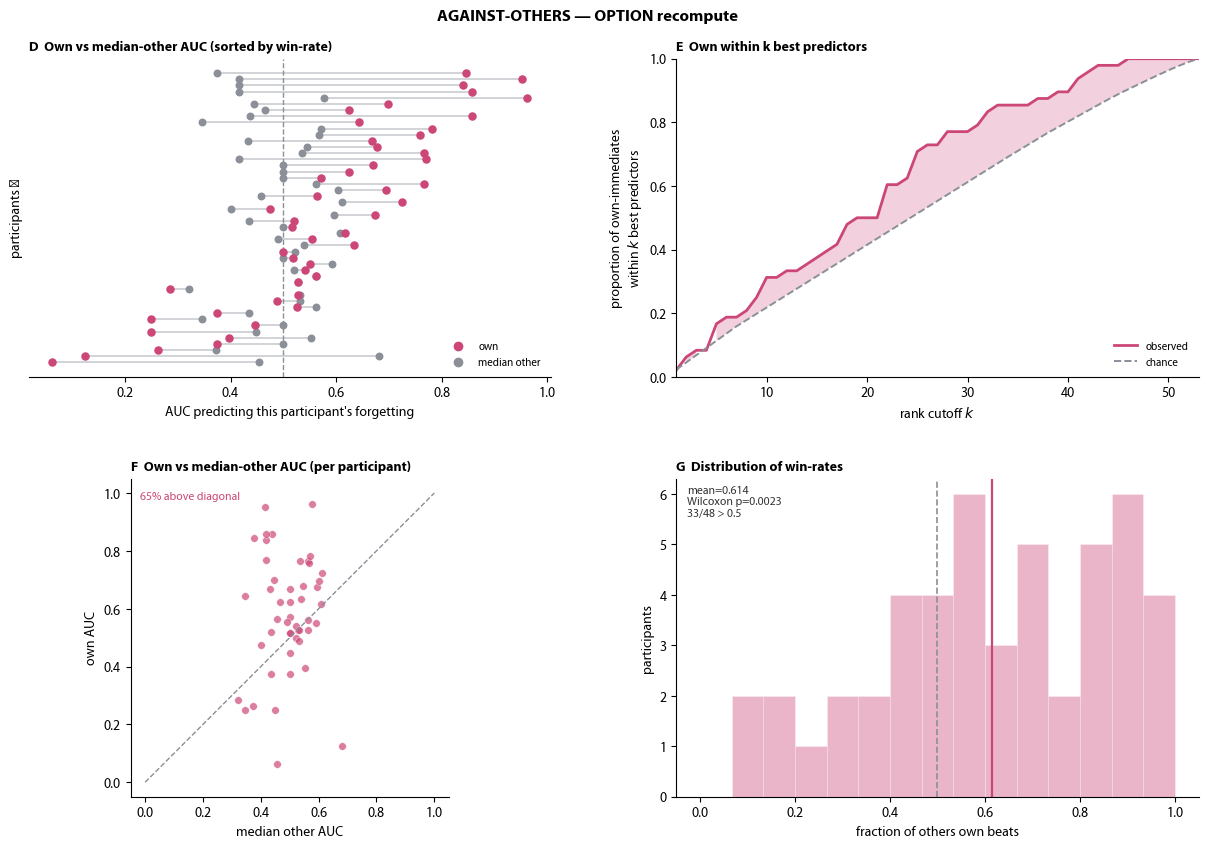

In [208]:
def compute_main(option):
    import pickle, numpy as np
    from collections import Counter
    import matplotlib; import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from scipy.stats import rankdata, wilcoxon
    
    d = rdp_upload_data
    # ---- build per-participant prominence data (drop-in for loading promstore.p) ----
    EPS = np.arange(0, 2, 0.1).round(1)

    def mean_center(a, b):
        c = np.mean([a.mean(0), b.mean(0)], axis=0)
        return a - c, b - c

    def rdp_ret(traj, epsilon, metric='cosine'):
        """Indices RDP retains when simplifying `traj` at `epsilon`."""
        traj = np.asarray(traj)
        def dist(pts, s, e):
            seg = e - s; Ln = np.dot(seg, seg)
            if Ln == 0:
                return cdist(pts, s[None], metric=metric).ravel()
            t = np.clip(np.dot(pts - s, seg) / Ln, 0, 1); proj = s + t[:, None] * seg
            return cdist(pts, proj, metric=metric).diagonal()
        def rec(idx):
            if len(idx) <= 2:
                return list(idx)
            dd = dist(traj[idx[1:-1]], traj[idx[0]], traj[idx[-1]]); k = int(np.argmax(dd))
            if dd[k] > epsilon:
                piv = k + 1
                return rec(idx[:piv + 1])[:-1] + rec(idx[piv:])
            return [idx[0], idx[-1]]
        return rec(list(range(len(traj))))

    NP=len(d['imm_rec_events']); MAG="#cc4778"; GREY="#8a8f98"
    store = {}
    for P in range(NP):
        imm_c, _ = mean_center(d['imm_rec_events'][P], d['del_rec_events'][P]); n = len(imm_c)
        imm_m = d['imm_event_matches'][P]; del_m = d['del_event_matches'][P]
        imm_cnt = Counter(imm_m[1:-1].tolist()); del_cnt = Counter(del_m.tolist())
        pool = set(imm_cnt.keys())
        # NOTE: this `forg` is the UN-adjusted def A; the script recomputes forgotten
        # via forg_adj (endpoint-symmetric), so store[P][3] is unused here.
        forg = set(e for e in imm_cnt if imm_cnt[e] > del_cnt.get(e, 0))
        # sweep epsilon upward; record the first epsilon at which each interior vertex is dropped
        fre = {}; prev = set(range(n))
        for e in EPS[1:]:
            ret = set(rdp_ret(imm_c, e))
            if ret != prev:
                for j in prev - ret:
                    if j not in fre:
                        fre[j] = e
                prev = ret
        for j in range(1, n - 1):
            fre.setdefault(j, EPS[-1])
        # episode-level prominence: first-removed occurrence (min epsilon) per episode event
        ep_fre = {}
        for j in range(1, n - 1):
            ep = int(imm_m[j]); ep_fre[ep] = min(ep_fre.get(ep, np.inf), fre[j])
        store[P] = (fre, ep_fre, pool, forg, imm_m, n)

    def forg_adj(P):
        imm_m=d['imm_event_matches'][P]; del_m=d['del_event_matches'][P]
        ii=Counter(imm_m[1:-1].tolist()); da=Counter(del_m.tolist()); ends=Counter([int(imm_m[0]),int(imm_m[-1])])
        return set(e for e in ii if ii[e]>max(0,da.get(e,0)-ends.get(e,0)))
    def auc_sub(prom, subset, forg):
        lab=np.array([1 if e in forg else 0 for e in subset]); n1=int(lab.sum()); n0=len(lab)-n1
        if n1==0 or n0==0: return None
        s=np.array([-prom[e] for e in subset]); r=rankdata(s)
        return (r[lab==1].sum()-n1*(n1+1)/2)/(n1*n0)
    prom=[store[P][1] for P in range(NP)]; pools=[store[P][2] for P in range(NP)]; forgs=[forg_adj(P) for P in range(NP)]
    valid=[P for P in range(NP) if 0<len(forgs[P]&pools[P])<len(pools[P])]
    own_full={a:auc_sub(prom[a],list(pools[a]),forgs[a]) for a in valid}

    def compute(option):  # 'recompute' or 'fixed'
        res={}
        for a in valid:
            own_vals=[]; oth_vals=[]
            for b in range(NP):
                if b==a: continue
                shared=[e for e in pools[a] if e in prom[b]]
                ab=auc_sub(prom[b],shared,forgs[a])
                if ab is None: continue
                if option=='recompute':
                    ao=auc_sub(prom[a],shared,forgs[a])
                    if ao is None: continue
                    own_vals.append(ao)
                else:
                    own_vals.append(own_full[a])
                oth_vals.append(ab)
            own_vals=np.array(own_vals); oth_vals=np.array(oth_vals)
            beats=(own_vals>oth_vals).astype(float)+0.5*(own_vals==oth_vals)
            wr=beats.mean()
            own_disp = own_full[a] if option=='fixed' else np.median(own_vals)
            own_rank=1+np.sum(oth_vals>own_vals)+0.5*np.sum(oth_vals==own_vals)
            res[a]=dict(wr=wr, own=own_disp, med_oth=np.median(oth_vals), own_rank=own_rank, M=1+len(oth_vals))
        return res

    def make_fig(res, title, fname):
        order=sorted(valid,key=lambda a:res[a]['wr'])
        wr=np.array([res[a]['wr'] for a in valid])
        fig=plt.figure(figsize=(13,9)); gs=gridspec.GridSpec(2,2,figure=fig,hspace=0.32,wspace=0.24,left=0.07,right=0.97,top=0.9,bottom=0.08)
        # D dumbbell
        axA=fig.add_subplot(gs[0,0])
        for i,a in enumerate(order):
            axA.plot([res[a]['med_oth'],res[a]['own']],[i,i],color=GREY,alpha=0.45,lw=1.2,zorder=1)
            axA.scatter(res[a]['med_oth'],i,s=22,color=GREY,zorder=2); axA.scatter(res[a]['own'],i,s=26,color=MAG,zorder=3)
        axA.axvline(0.5,color=GREY,ls='--',lw=1); axA.set_yticks([])
        axA.set_title("D  Own vs median-other AUC (sorted by win-rate)",loc='left',fontsize=10,fontweight='bold')
        axA.set_xlabel("AUC predicting this participant's forgetting"); axA.set_ylabel("participants →")
        axA.scatter([],[],color=MAG,label='own'); axA.scatter([],[],color=GREY,label='median other'); axA.legend(fontsize=8,frameon=False,loc='lower right')
        for s in ['top','right','left']: axA.spines[s].set_visible(False)
        # E rank-cutoff
        Ms=[res[a]['M'] for a in valid]; ranks=[res[a]['own_rank'] for a in valid]; kmax=int(max(Ms)); ks=np.arange(1,kmax+1)
        obs=np.array([np.mean([ranks[i]<=k for i in range(len(valid))]) for k in ks])
        cha=np.array([np.mean([min(k,Ms[i])/Ms[i] for i in range(len(valid))]) for k in ks])
        axB=fig.add_subplot(gs[0,1])
        axB.fill_between(ks,cha,obs,where=(obs>=cha),color=MAG,alpha=0.25,lw=0)
        axB.plot(ks,obs,color=MAG,lw=2,label='observed'); axB.plot(ks,cha,'--',color=GREY,lw=1.4,label='chance')
        axB.set_title("E  Own within k best predictors",loc='left',fontsize=10,fontweight='bold')
        axB.set_xlabel("rank cutoff $k$"); axB.set_ylabel("proportion of own-immediates\nwithin $k$ best predictors")
        axB.set_xlim(1,kmax); axB.set_ylim(0,1); axB.legend(fontsize=8,frameon=False,loc='lower right')
        for s in ['top','right']: axB.spines[s].set_visible(False)
        # F scatter
        axC=fig.add_subplot(gs[1,0]); ox=[res[a]['med_oth'] for a in valid]; oy=[res[a]['own'] for a in valid]
        axC.plot([0,1],[0,1],'--',color=GREY,lw=1); axC.scatter(ox,oy,s=30,color=MAG,alpha=0.7,edgecolor='white',lw=0.4)
        above=np.mean(np.array(oy)>np.array(ox))
        axC.set_title("F  Own vs median-other AUC (per participant)",loc='left',fontsize=10,fontweight='bold')
        axC.set_xlabel("median other AUC"); axC.set_ylabel("own AUC"); axC.set_aspect('equal')
        axC.annotate(f"{above*100:.0f}% above diagonal",xy=(0.03,0.96),xycoords='axes fraction',va='top',fontsize=8.5,color=MAG)
        for s in ['top','right']: axC.spines[s].set_visible(False)
        # G win-rate dist
        axD=fig.add_subplot(gs[1,1]); axD.hist(wr,bins=np.linspace(0,1,16),color=MAG,alpha=0.4,edgecolor='white',lw=0.5)
        axD.axvline(0.5,color=GREY,ls='--',lw=1.2); axD.axvline(wr.mean(),color=MAG,lw=1.6)
        pw=wilcoxon(wr-0.5,alternative='greater').pvalue
        axD.set_title("G  Distribution of win-rates",loc='left',fontsize=10,fontweight='bold')
        axD.set_xlabel("fraction of others own beats"); axD.set_ylabel("participants")
        axD.annotate(f"mean={wr.mean():.3f}\nWilcoxon p={pw:.4f}\n{int((wr>0.5).sum())}/{len(wr)} > 0.5",xy=(0.02,0.98),xycoords='axes fraction',va='top',fontsize=8.5,color='#333')
        for s in ['top','right']: axD.spines[s].set_visible(False)
        fig.suptitle(title,y=0.955,fontsize=12,fontweight='bold')
        return wr.mean(), pw, fig
    
    r1=compute(option)
    m1,p1,fig=make_fig(r1,f"AGAINST-OTHERS — OPTION {option}", "")
    print(f"{option}: mean win-rate={m1:.3f} p={p1:.4f}")
    plt.show()
compute_main('recompute')

In [122]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon



# ---- RDP core ----
def _perp(pts, s, e):
    seg = e - s; L = float(seg @ seg)
    if L == 0: return np.linalg.norm(pts - s, axis=1)
    t = np.clip((pts - s) @ seg / L, 0, 1); proj = s + t[:, None] * seg
    return np.linalg.norm(pts - proj, axis=1)

def rdp_keep(P, eps):
    P = np.asarray(P)
    def rec(idx):
        if len(idx) <= 2: return list(idx)
        d = _perp(P[idx[1:-1]], P[idx[0]], P[idx[-1]]); k = int(np.argmax(d))
        if d[k] > eps:
            piv = k + 1; return rec(idx[:piv + 1])[:-1] + rec(idx[piv:])
        return [idx[0], idx[-1]]
    return sorted(rec(list(range(len(P)))))

def rdp_steps(P, eps):
    P = np.asarray(P); n = len(P)
    steps = []; kept = {0, n - 1}; dropped = set()
    def rec(lo, hi):
        inner = list(range(lo + 1, hi))
        if not inner: return
        d = _perp(P[inner], P[lo], P[hi]); kk = int(np.argmax(d)); k = inner[kk]; dev = float(d[kk])
        keep = dev > eps
        steps.append(dict(lo=lo, hi=hi, test=k, keep=keep, kept=set(kept), dropped=set(dropped)))
        if keep:
            kept.add(k); rec(lo, k); rec(k, hi)
        else:
            dropped.update(inner)
    rec(0, n - 1)
    return steps


# ---- geometry for limits ----
def _limits():
    (xmin, ymin), (xmax, ymax) = PATH.min(0), PATH.max(0)
    xspan = (xmax - xmin) or 1.0; yspan = (ymax - ymin) or 1.0
    x0 = xmin - PAD_LEFT * xspan;  x1 = xmax + PAD_RIGHT * xspan
    y0 = ymin - PAD_BOTTOM * yspan; y1 = ymax + PAD_TOP * yspan
    return x0, x1, y0, y1


# ---- drawing helpers ----
def _band_poly(S, E, eps):
    d = E - S; u = d / np.linalg.norm(d); p = np.array([-u[1], u[0]])
    return np.array([S + eps * p, E + eps * p, E - eps * p, S - eps * p])

def draw_band(ax, S, E):  ax.add_patch(Polygon(_band_poly(S, E, EPSILON), closed=True, facecolor=C_BAND, edgecolor='none', zorder=0))
def draw_chord(ax, S, E): ax.plot([S[0], E[0]], [S[1], E[1]], color=C_CHORD, lw=LW_CHORD, zorder=3, solid_capstyle='round')
def draw_line(ax, idxs, color=C_CURVE, lw=LW_CURVE, ls='-', z=1, alpha=1.0):
    pts = PATH[np.asarray(idxs)]; ax.plot(pts[:, 0], pts[:, 1], ls, color=color, lw=lw, alpha=alpha, zorder=z, solid_capstyle='round')
def draw_pts(ax, idxs, color=C_POINT, s=S_POINT):
    for i in idxs: ax.scatter(*PATH[i], s=s, color=color, edgecolor='white', lw=0.7, zorder=5)
def draw_ghost(ax, i): ax.scatter(*PATH[i], s=S_GHOST, color=C_GHOST, edgecolor='white', lw=0.6, zorder=4)
def draw_ring(ax, i, keep):
    ax.scatter(*PATH[i], s=S_RING, facecolor='none', edgecolor=RING_EDGE, lw=1.6, zorder=6)
    ax.scatter(*PATH[i], s=S_HILITE, color=(C_KEEP if keep else C_DROP), edgecolor='white', lw=0.8, zorder=7)
def draw_eps(ax, S, E):
    u = (E - S) / np.linalg.norm(E - S); p = np.array([-u[1], u[0]])
    ax.annotate('', xy=S + EPSILON * p, xytext=S, arrowprops=dict(arrowstyle='<->', color='#333', lw=1.2))
    lab = S + 0.5 * EPSILON * p; ax.text(lab[0] - 0.045 * np.ptp(PATH[:, 0]), lab[1], 'ε', fontsize=14, va='center', ha='center', color='#333')

def _setup(ax):
    x0, x1, y0, y1 = _limits()
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
    ax.set_aspect('equal', adjustable='box')   # frame hugs the padded limits; band undistorted
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_linewidth(0.6)


# ---- panels ----
def draw_step(ax, step):
    n = len(PATH); lo, hi, k, keep = step['lo'], step['hi'], step['test'], step['keep']
    kept, dropped = step['kept'], step['dropped']
    marks = sorted(set(kept) | {lo, hi})
    for a, b in zip(marks, marks[1:]):
        interior = list(range(a + 1, b))
        if interior and all(j in dropped for j in interior):
            draw_line(ax, [a, b], C_ENDPT, LW_SIMPL, z=2)
        else:
            draw_line(ax, range(a, b + 1), C_CURVE, LW_CURVE, z=1)
    draw_band(ax, PATH[lo], PATH[hi]); draw_chord(ax, PATH[lo], PATH[hi])
    for i in range(n):
        if i in dropped: draw_ghost(ax, i)
        elif i in kept or i in (lo, hi): draw_pts(ax, [i], C_ENDPT)
        else: draw_pts(ax, [i], C_POINT)
    draw_ring(ax, k, keep)
    if SHOW_EPS_LABEL and lo == 0 and hi == n - 1: draw_eps(ax, PATH[lo], PATH[hi])

def draw_final(ax):
    n = len(PATH); keep = rdp_keep(PATH, EPSILON); drop = [i for i in range(n) if i not in keep]
    draw_line(ax, range(n), C_ORIG, LW_DASH, z=0)
    draw_line(ax, keep, C_ENDPT, LW_SIMPL, z=2)
    for i in drop: draw_ghost(ax, i)
    draw_pts(ax, keep, C_ENDPT, S_ENDPT)


def render(axis_on=True):
    steps = rdp_steps(PATH, EPSILON); n_panels = len(steps) + 1
    x0, x1, y0, y1 = _limits(); box_aspect = (x1 - x0) / (y1 - y0)
    ph = FIG_WIDTH / box_aspect
    fig, axes = plt.subplots(n_panels, 1, figsize=(FIG_WIDTH, n_panels * ph + (n_panels - 1) * ph * HSPACE))
    axes = np.atleast_1d(axes)
    for ax in axes: _setup(ax)
    for i, step in enumerate(steps): draw_step(axes[i], step)
    draw_final(axes[-1])
    if SHOW_STEP_NUMBERS:
        for k, ax in enumerate(axes):
            ax.text(0.015, 0.92, str(k + 1), transform=ax.transAxes, fontsize=12, fontweight='bold', va='top', color='#999')
    if not axis_on:
        for ax in fig.axes:
            ax.axis('off')
    fig.subplots_adjust(hspace=HSPACE, left=0.02, right=0.98, top=0.99, bottom=0.01)
    plt.show()
    return n_panels, box_aspect

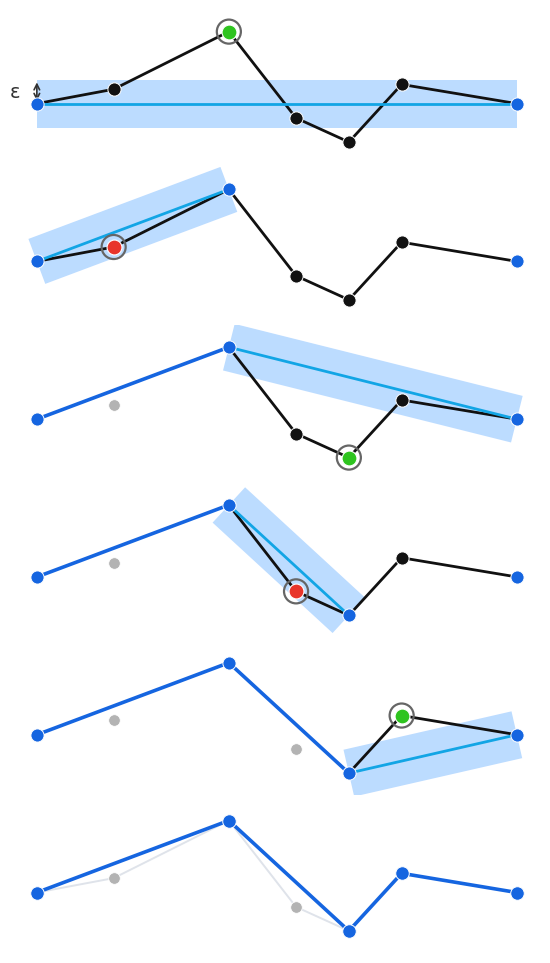

(6, np.float64(3.416149068322981))

In [161]:
# ============================== CONFIG ==============================


FIG_WIDTH        = 5.5
HSPACE           = 0
SHOW_STEP_NUMBERS= False
SHOW_EPS_LABEL   = True

# colors
C_CURVE='#111111'
C_POINT='#111111'
C_ENDPT='#1565e0'            # active-segment endpoints & simplified path (blue)
C_CHORD='#12a5e5'            # chord (cyan)
C_BAND ='#bcdcff'            # epsilon band (light blue)
C_KEEP ='#2ec41f'           # tested point outside band -> kept (green)
C_DROP ='#e8352b'           # tested point inside band  -> dropped (red)
C_GHOST='#b3b3b3'           # already-dropped points (grey)
C_ORIG ='#dfe3ea'           # faint original curve in the final panel
RING_EDGE='#666666'

# sizes / linewidths
LW_CURVE=2.0
LW_CHORD=2.0
LW_SIMPL=2.6
LW_DASH=1.4
S_POINT=90
S_ENDPT=95
S_HILITE=115
S_RING=300
S_GHOST=70

PAD_LEFT   = 0.05
PAD_RIGHT  = 0.05
PAD_TOP    = 0.2
PAD_BOTTOM = 0.2


EPSILON = 0.05
PATH = np.array([
    [0.00, 0.5],
    [0.16, 0.53],
    [0.4, 0.65],
    [0.54, 0.47],
    [0.65, 0.42],
    [0.76, 0.54],
    [1.0, 0.5]
])

render(False)

In [210]:
"""
Own-vs-episode removal-order analysis.

Question
--------
Does the removal order (RDP epsilon-at-removal) of events in a participant's OWN
immediate recall predict which events they forget, over and above the removal
order of the events in the EPISODE?  Evidence for "delayed recall simplifies your
own immediate recall, not the episode" is: own predicts, episode does not.

The unit of analysis is the event (a participant x episode observation).  For each
event we have two removal-order scores -- one from the participant's own recall
trajectory, one from the fixed episode trajectory -- and a binary forgotten label.

PART 1 (primary): event-level joint logistic
    forgotten ~ own_z + episode_z
    with a participant-blocked label permutation giving p-values for the own
    coefficient, the episode coefficient, and the own - episode contrast.

PART 2 (robustness): re-estimate the own_z coefficient while controlling for
    episode identity -- and then also participant identity -- as FIXED effects
    (a stronger control than random intercepts), again with participant-blocked
    permutation.  Episode fixed effects subsume episode_z (collinear with it).

Conventions (all matched to the main AUC analysis)
--------------------------------------------------
* RDP with COSINE deviation in the 768-D embedding space; threshold grid step 0.1.
* Endpoints of a trajectory are never scored by RDP and are excluded (not imputed).
* Own trajectory mean-centered on the shared immediate+delayed centroid; the episode
  trajectory on its own centroid.
* Own epsilon is reduced to episode level by the MIN over repeated recalls.
* "Forgotten" = endpoint-symmetric def A (see forgotten_defA).
* Common pool: an event enters only if BOTH scores are defined -- i.e. it is an
  interior immediate-recall event AND an episode-interior event (episodes 1..18).
* Predictors are within-participant z-scored "forgettability" (= -epsilon), so a
  positive coefficient means "more disposable -> more likely forgotten" and the two
  predictors are on a common per-SD scale.
* p-values come from permuting forgotten labels WITHIN each participant (preserving
  each person's structure and base rate), which accounts for participant clustering.
"""
import pickle
import numpy as np
from collections import Counter
from scipy.spatial.distance import cdist
from scipy.optimize import minimize

# ------------------------------- config -------------------------------
EPS         = np.arange(0, 2, 0.1).round(1)   # RDP threshold grid
MIN_POOL    = 4                               # min common-pool events per participant
RIDGE       = 1.0                             # L2 on fixed-effect dummies (Part 2 only)
N_PERM      = 6000                            # permutations, Part 1
N_PERM_FE_B = 2000                            # permutations, robustness model B
N_PERM_FE_C = 800                             # permutations, robustness model C (slower)
SEED        = 1


# ------------------------------- RDP core -------------------------------
def mean_center(a, b):
    """Center both point sets on the mean of their two centroids (shared origin)."""
    c = np.mean([a.mean(0), b.mean(0)], axis=0)
    return a - c, b - c


def rdp_retained(traj, eps, metric="cosine"):
    """Indices retained by Ramer-Douglas-Peucker at threshold eps."""
    traj = np.asarray(traj)

    def dev(pts, s, e):
        seg = e - s
        L = float(seg @ seg)
        if L == 0:
            return cdist(pts, s[None], metric=metric).ravel()
        t = np.clip((pts - s) @ seg / L, 0, 1)
        proj = s + t[:, None] * seg
        return cdist(pts, proj, metric=metric).diagonal()

    def rec(idx):
        if len(idx) <= 2:
            return list(idx)
        dd = dev(traj[idx[1:-1]], traj[idx[0]], traj[idx[-1]])
        k = int(np.argmax(dd))
        if dd[k] > eps:
            piv = k + 1
            return rec(idx[:piv + 1])[:-1] + rec(idx[piv:])
        return [idx[0], idx[-1]]

    return rec(list(range(len(traj))))


def removal_order(traj):
    """First-removal epsilon per INTERIOR vertex (endpoints excluded -> no key).
    Interior vertices never removed get the grid max.  Returns {vertex: eps}."""
    n = len(traj)
    fre = {}
    prev = set(range(n))
    for e in EPS[1:]:
        ret = set(rdp_retained(traj, e))
        if ret != prev:
            for j in prev - ret:
                fre.setdefault(j, e)
            prev = ret
    for j in range(1, n - 1):
        fre.setdefault(j, EPS[-1])
    return fre                              # keys 1..n-2 only


def forgotten_defA(P, d):
    """Endpoint-symmetric def A: an episode is forgotten if matched by more interior
    immediate-recall events than delayed events (crediting the two immediate endpoints)."""
    im = d["imm_event_matches"][P]
    dm = d["del_event_matches"][P]
    ii = Counter(im[1:-1].tolist())
    da = Counter(dm.tolist())
    ends = Counter([int(im[0]), int(im[-1])])
    return set(e for e in ii if ii[e] > max(0, da.get(e, 0) - ends.get(e, 0)))


# ------------------------- build event-level dataset -------------------------
def build_events(d):
    """One row per (participant, episode) event on the common pool.  Returns arrays:
    pid, eid, own_z, epi_z, y  (y = forgotten)."""
    EP = d["episode_events"]
    episode_eps = removal_order(EP - EP.mean(0))          # fixed episode removal order (1..18)
    NP = len(d["imm_rec_events"])
    pid, eid, own_z, epi_z, y = [], [], [], [], []
    for P in range(NP):
        imm_c, _ = mean_center(d["imm_rec_events"][P], d["del_rec_events"][P])
        n = len(imm_c)
        im = d["imm_event_matches"][P]
        fre = removal_order(imm_c)
        own_eps = {}                                      # episode-level own eps (min over repeats)
        for j in range(1, n - 1):
            e = int(im[j])
            own_eps[e] = min(own_eps.get(e, np.inf), fre[j])
        forg = forgotten_defA(P, d)
        pool = sorted(e for e in own_eps if e in episode_eps)   # common pool
        lab = np.array([1 if e in forg else 0 for e in pool])
        if len(pool) < MIN_POOL or not (0 < lab.sum() < len(lab)):
            continue
        ov = np.array([own_eps[e] for e in pool], float)
        ev = np.array([episode_eps[e] for e in pool], float)
        if ov.std() == 0 or ev.std() == 0:
            continue
        oz = -(ov - ov.mean()) / ov.std()                 # within-participant forgettability z
        ez = -(ev - ev.mean()) / ev.std()
        for k, e in enumerate(pool):
            pid.append(P); eid.append(e); own_z.append(oz[k]); epi_z.append(ez[k]); y.append(lab[k])
    return (np.array(pid), np.array(eid), np.array(own_z, float),
            np.array(epi_z, float), np.array(y, float))


# ------------------------- logistic fit + permutation -------------------------
def fit_logit(X, y, pen=None):
    """MLE logistic coefficients; optional per-column L2 penalty (pen: length-k array)."""
    pen = np.zeros(X.shape[1]) if pen is None else pen

    def nll(b):
        z = X @ b
        return np.sum(np.logaddexp(0, z) - y * z) + np.sum(pen * b * b)

    return minimize(nll, np.zeros(X.shape[1]), method="BFGS").x


def blocked_null(X, y, pid, coef_idx, n_perm, seed, pen=None):
    """Null distribution of coefficient(s) under within-participant label permutation.
    coef_idx may be an int or a list; returns array shape (n_perm,) or (n_perm, k)."""
    idx = np.atleast_1d(coef_idx)
    rng = np.random.default_rng(seed)
    blocks = [np.where(pid == p)[0] for p in set(pid)]
    out = np.empty((n_perm, len(idx)))
    for i in range(n_perm):
        yp = y.copy()
        for ix in blocks:
            yp[ix] = rng.permutation(yp[ix])
        out[i] = fit_logit(X, yp, pen)[idx]
    return out.squeeze()


def onehot(v):
    return np.column_stack([(v == x).astype(float) for x in sorted(set(v))])


# ==============================================================================
#                                    MAIN
# ==============================================================================
def main():
    d = rdp_upload_data
    pid, eid, own_z, epi_z, y = build_events(d)
    print("events=%d  participants=%d  episodes=%d  forgotten=%d\n"
          % (len(y), len(set(pid)), len(set(eid)), int(y.sum())))

    # ----------------------------------------------------------------------
    # PART 1  primary joint logistic:  forgotten ~ own_z + episode_z
    # ----------------------------------------------------------------------
    print("=== PART 1: joint logistic  forgotten ~ own_z + episode_z ===")
    X = np.column_stack([np.ones(len(y)), own_z, epi_z])          # [intercept, own, episode]
    b = fit_logit(X, y)
    own_obs, epi_obs = b[1], b[2]
    diff_obs = own_obs - epi_obs
    # own & episode nulls from the SAME permutations so their difference is paired
    nulls = blocked_null(X, y, pid, [1, 2], N_PERM, SEED)
    own_null, epi_null = nulls[:, 0], nulls[:, 1]
    diff_null = own_null - epi_null
    print("  own      coef=%+.3f   one-sided p(>=obs) = %.4f" % (own_obs, np.mean(own_null >= own_obs)))
    print("  episode  coef=%+.3f   two-sided p        = %.4f" % (epi_obs, np.mean(np.abs(epi_null) >= abs(epi_obs))))
    print("  own - episode = %+.3f  one-sided p(>=obs) = %.4f" % (diff_obs, np.mean(diff_null >= diff_obs)))

    # ----------------------------------------------------------------------
    # PART 2  fixed-effects robustness for the own_z coefficient
    #   A: own_z + episode_z                       (baseline, = Part 1 own)
    #   B: own_z + episode fixed effects           (episode identity; subsumes episode_z)
    #   C: own_z + episode FE + participant FE      (both identities)
    # Episode/participant dummies span the intercept; a small L2 (RIDGE) on the
    # dummies stabilizes near-separated cells.  own_z is left unpenalized.
    # ----------------------------------------------------------------------
    print("\n=== PART 2: fixed-effects robustness (own_z coefficient) ===")
    epD = onehot(eid)                                             # 18 episode dummies
    ptD = onehot(pid)                                             # participant dummies

    # Model A -- own_z + episode_z (+ intercept)
    XA = np.column_stack([np.ones(len(y)), own_z, epi_z])
    bA = fit_logit(XA, y)
    pA = np.mean(blocked_null(XA, y, pid, 1, N_PERM_FE_B, SEED + 10) >= bA[1])
    print("  A  own_z + episode_z              : own coef=%+.3f  perm p=%.4f" % (bA[1], pA))

    # Model B -- own_z + episode fixed effects (dummies span the intercept)
    XB = np.column_stack([own_z, epD])
    penB = np.r_[0.0, RIDGE * np.ones(epD.shape[1])]
    bB = fit_logit(XB, y, penB)
    pB = np.mean(blocked_null(XB, y, pid, 0, N_PERM_FE_B, SEED + 20, pen=penB) >= bB[0])
    print("  B  own_z + episode FE             : own coef=%+.3f  perm p=%.4f   (episode_z subsumed)" % (bB[0], pB))

    # Model C -- own_z + episode FE + participant FE (drop one participant dummy)
    XC = np.column_stack([own_z, epD, ptD[:, 1:]])
    penC = np.r_[0.0, RIDGE * np.ones(epD.shape[1] + ptD.shape[1] - 1)]
    bC = fit_logit(XC, y, penC)
    pC = np.mean(blocked_null(XC, y, pid, 0, N_PERM_FE_C, SEED + 30, pen=penC) >= bC[0])
    print("  C  own_z + episode FE + participant FE : own coef=%+.3f  perm p=%.4f" % (bC[0], pC))
    
main()

events=711  participants=47  episodes=18  forgotten=143

=== PART 1: joint logistic  forgotten ~ own_z + episode_z ===
  own      coef=+0.242   one-sided p(>=obs) = 0.0037
  episode  coef=+0.012   two-sided p        = 0.9012
  own - episode = +0.230  one-sided p(>=obs) = 0.0480

=== PART 2: fixed-effects robustness (own_z coefficient) ===
  A  own_z + episode_z              : own coef=+0.242  perm p=0.0030
  B  own_z + episode FE             : own coef=+0.230  perm p=0.0020   (episode_z subsumed)
  C  own_z + episode FE + participant FE : own coef=+0.239  perm p=0.0037
